# Méthodes de plongements (Embedding & Manifold learning)

## 1. Réduction de dimensionalité

On peut considérer que le but de la réduction de dimension est de retrouver les variables cachées (**variable latentes**) qui **décrivent au mieux nos données**, à partir des variables observées qui nous sont accessibles.

###  Intéret de la réduction de dimensionalité

Dans un jeu de données sous forme tabulaire contenant $n$ observations et $p$ variables, on cherche à réduire ce nombre à m variables ($m < p$) afin de trouver un **équilibre** entre **"résumer" les données** (sans trop de perte d'information) et **conserver de bonnes performances de nos modèles** utilisant ces $m$ variables comme résumé des $p$ variables.
En pratique, la réduction de dimensionalité, présente **trois principaux avantages**: 
- Réduire les coups computationnels: **stockage & acquisition** de données (par compression), **temps de calcul**
- **Visualiser** plus facilement un dataset de **haute dimension**
- Améliorer la qualité des modèles d'apprentissage: en éliminant des **variables non pertinentes** qui pourraient **dégrader les performances** des modeles, réduisant le problème du **fléau de la dimensionalité** et surtout en construisant des **modèles moins complexes**, **plus parcimonieux**

### 1.1 La notion de plongement

Afin de trouver les variables latentes, on cherche alors à construire, à partir d'un espace de départ $E_{depart}$, un nouvel espace de représentation des données ($E_{arrivee}$) qui **exploitent mieux les caractéristiques intrisèques des données** (comme par exemple trouver un espace dont les vecteurs de base maximisent direction de la variance des données). Le plongement se carctérise alors par une fonction [injective](https://en.wikipedia.org/wiki/Injective_function) $f$ permettant de lier n'importe quel point de l'espace de départ $E_{depart}$ à l'espace d'arrivée $E_{arrivee}$ en **préservant la structure de $E_{depart}$**. 

#### 1.1.1 Plongemement linéaires

Dans un espace vectoriel canonique $E_{depart}$, on peut décrire notre jeu de données par une matrice dans laquelle chaque colonne correspond à chacune des $p$ variables du jeu de données $X_1, X_2 \dots X_p$: 
$$ X=\begin{bmatrix} X_{11} & \cdots & X_{1p} \\ \vdots & \ddots & \vdots \\ X_{n1} & \cdots & X_{np}\end{bmatrix} $$


Lorsque l'on réalise un plongement linéaire, on cherche le nouvel espace $E_{arrivee}$ dans lequel les vecteurs de base décrivant $E_{arrivee}$, correspondent à de nouvelles variables $Z_1, Z_2 \dots Z_p$ qui décrivent notre jeu de données. Le plongement linéaire $f$ peut alors se décrire par une [matrice de projection](https://fr.wikipedia.org/wiki/Projecteur_(math%C3%A9matiques)) $W$ transformant la matrice $X$ en $Z$ :
$$Z = W^{T}X$$

#### Factorisation de matrices : vecteurs propres valeurs propres

Dans la plupart des cas de plongement linéaires, on cherche à écrire la matrice $W$ sous une **forme factorisée** dans laquelle les éléments diagonaux **$\lambda_i$** sont les **valeurs propres** de $W$. Les colonnes de $W$ sont **les vecteurs propres** et peuvent s'interpréter comme les vecteurs de base du nouvel espace d'arrivée $E_{arrivee}$

Cette méthode de factorisation permet d'obtenir avec $Z$ une **représentation latente des données**.

<details>
    <summary> Détails de calcul des vecteurs propres </summary>
            Mathématiquement, pour trouver les valeurs propres $\lambda_i$ et vecteurs propres $v$ d'une matrice $M$ carrée de  dimension <i>n</i> on cherche à résoudre : $ Mv =\lambda v $.
Pour des détails complets concernant leurs calcul, vous pouvez regardez <a href="https://www.youtube.com/watch?v=doZI0UJ0FY0"> cette vidéo </a>     
</details>

#### 1.1.1.1 Exemple de l'Analyse en Composante Principale (ACP)

L'ACP est l'une des méthodes de plongements linéaires les plus populaires, elle se calcule par factorisation de la matrice de covariance des $p$ variables: 
$$ \sigma_{ij}=\begin{bmatrix} \sigma_{11}^2 & \cdots & \sigma_{1p} \\ \vdots & \ddots & \vdots \\ \sigma_{p1} & \cdots & \sigma_{pp}^2 \end{bmatrix}$$ qui devient une fois **factorisée** et **normalisée**:
$$ \sigma_{ij}=\begin{bmatrix} \lambda_{11}^2 & \cdots & 0 \\ \vdots & \ddots & \vdots \\ 0 & \cdots & \lambda_{pp}^2 \end{bmatrix}$$

*où les valeurs propres $\lambda_i$ représentent le pourcentage de variance expliquée par chacune des vecteurs propres de $\sigma_{ij}$*


Les caractéristiques de cette méthode de plongement se résument ainsi :
- Les **composantes principales** forment une **base orthonormée** et sont construites pour que les données aient une **variance maximale selon ces nouveaux axes**.

- Les **composantes principales** sont en fait les **vecteurs propres** de la **matrice de covariance** des données, classées par ordre décroissant de valeur propre correspondante.

- Pour choisir le nombre de composantes à utiliser à conserver pour "résumer" nos données, on regarde la **proportion de la variance totale expliquée par k composantes**. 

En général, pour trouver une valeur équilibrée de k dans laquelle réduit le plus les variables de notre dataset tout en conservant une pourcentage de variance expliquée important, on utilise **[la méthode du coude](https://openclassrooms.com/fr/courses/4379436-explorez-vos-donnees-avec-des-algorithmes-non-supervises/4379481-calculez-les-composantes-principales-de-vos-donnees#/id/r-6814070)** qui consiste à repérer le point d'inflexion dans la courbe de l'importance relative des valeurs propres.


<details>
    <summary> <b> Pour aller plus loin </b> </summary>
        Vous trouverez <a href='https://stats.stackexchange.com/questions/2691/making-sense-of-principal-component-analysis-eigenvectors-eigenvalues/140579#140579'> ici </a> une explication vulgarisée de la création de l'axe de l'ACP ainsi qu'un outil de visualisation <a href='https://setosa.io/ev/principal-component-analysis/'> ici </a>
</details>

#### Exemple d'application de l'ACP

Pour cet exemple d'application nous allons utiliser un jeu de données contenant 41 variables décrivant les performances d'athlètes à une compétition de décathlon :

In [8]:
import pandas as pd

# charger les données
data = pd.read_csv('http://factominer.free.fr/factomethods/datasets/decathlon.txt', sep="\t")

# éliminer les colonnes que nous n'utiliserons pas
my_data = data.drop(['Points', 'Rank', 'Competition'], axis=1)
my_data.head()

# transformer les données en array numpy
X = my_data.values

my_data

,100m,Long.jump,Shot.put,High.jump,400m,110m.hurdle,Discus,Pole.vault,Javeline,1500m
SEBRLE,11.04,7.58,14.83,2.07,49.81,14.69,43.75,5.02,63.19,291.70
CLAY,10.76,7.40,14.26,1.86,49.37,14.05,50.72,4.92,60.15,301.50
KARPOV,11.02,7.30,14.77,2.04,48.37,14.09,48.95,4.92,50.31,300.20
BERNARD,11.02,7.23,14.25,1.92,48.93,14.99,40.87,5.32,62.77,280.10
YURKOV,11.34,7.09,15.19,2.10,50.42,15.31,46.26,4.72,63.44,276.40
WARNERS,11.11,7.60,14.31,1.98,48.68,14.23,41.10,4.92,51.77,278.10
ZSIVOCZKY,11.13,7.30,13.48,2.01,48.62,14.17,45.67,4.42,55.37,268.00
McMULLEN,10.83,7.31,13.76,2.13,49.91,14.38,44.41,4.42,56.37,285.10
MARTINEAU,11.64,6.81,14.57,1.95,50.14,14.93,47.60,4.92,52.33,262.10
HERNU,11.37,7.56,14.41,1.86,51.10,15.06,44.99,4.82,57.19,285.10


Le calcul de l'ACP fait l'hypothèse que les données sont centrées, nous leur commençons donc par les standardiser:

In [2]:
from sklearn import preprocessing

std_scale = preprocessing.StandardScaler().fit(X)
X_scaled = std_scale.transform(X)

Calculons maintenant les composantes principales :

In [3]:
from sklearn import decomposition

pca = decomposition.PCA(n_components=X.shape[1])
pca.fit(X_scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",10
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD

Représentons maintenant la courbe de l'ébouli des valeurs propres afin de déterminer le nombre $k$ de composantes à conserver dans notre réduction de dimensionalité:

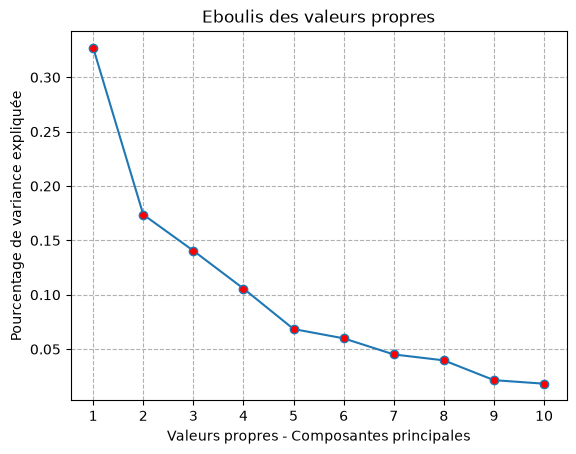

In [4]:
import matplotlib as mpl
import matplotlib.pyplot as plt

plt.plot(range(1,my_data.shape[1]+1), pca.explained_variance_ratio_, marker="o", markerfacecolor="r")
plt.xlabel('Valeurs propres - Composantes principales'); 
plt.xticks(range(1,my_data.shape[1]+1))
plt.ylabel('Pourcentage de variance expliquée');
plt.grid(linestyle='--')
plt.title("Eboulis des valeurs propres");

La courbe semble faire apparaitre un coude autour de **k=5**, les 5 premières composantes expliquant déja plus de 81% de la variance:

In [5]:
print(pca.explained_variance_ratio_[0:6].sum())

0.8754845812164901


Représentons certaines des composantes sélectionnées:

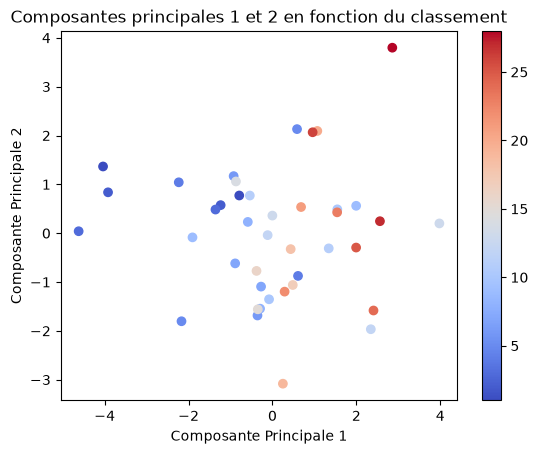

In [6]:
# projeter X sur les composantes principales
X_projected = pca.transform(X_scaled)

# afficher chaque observation des deux 1eres composantes
plt.scatter(X_projected[:, 0], X_projected[:, 1],
    # colorer en utilisant la variable 'Rank'            
    c=data['Rank'], cmap='coolwarm');

plt.xlabel("Composante Principale 1");
plt.ylabel("Composante Principale 2");
plt.title("Composantes principales 1 et 2 en fonction du classement")
plt.colorbar();

En explorant un peu les données dans l'espace des composantes, on s'aperçoit que les mauvaises performances (couleurs froides) sont plutôt situées dans la partie droite du graphe alors que les bonnes performances (couleurs chaudes) plutôt dans la partie gauche. Ceci suggère que la composante principale 1 discrimine plutôt bien les performances globales des athlètes.
</details>

<details>
    <summary> Remarque </summary>
        Ici certaines composantes principales se trouvent être relativement discriminantes (la 1ère des performances globales), mais ca n'est pas une garantie de manière générale, surtout lorsque les données présentes des aspects non linéaires.
</details>

**Contribution de chaque variable aux composantes principales :**

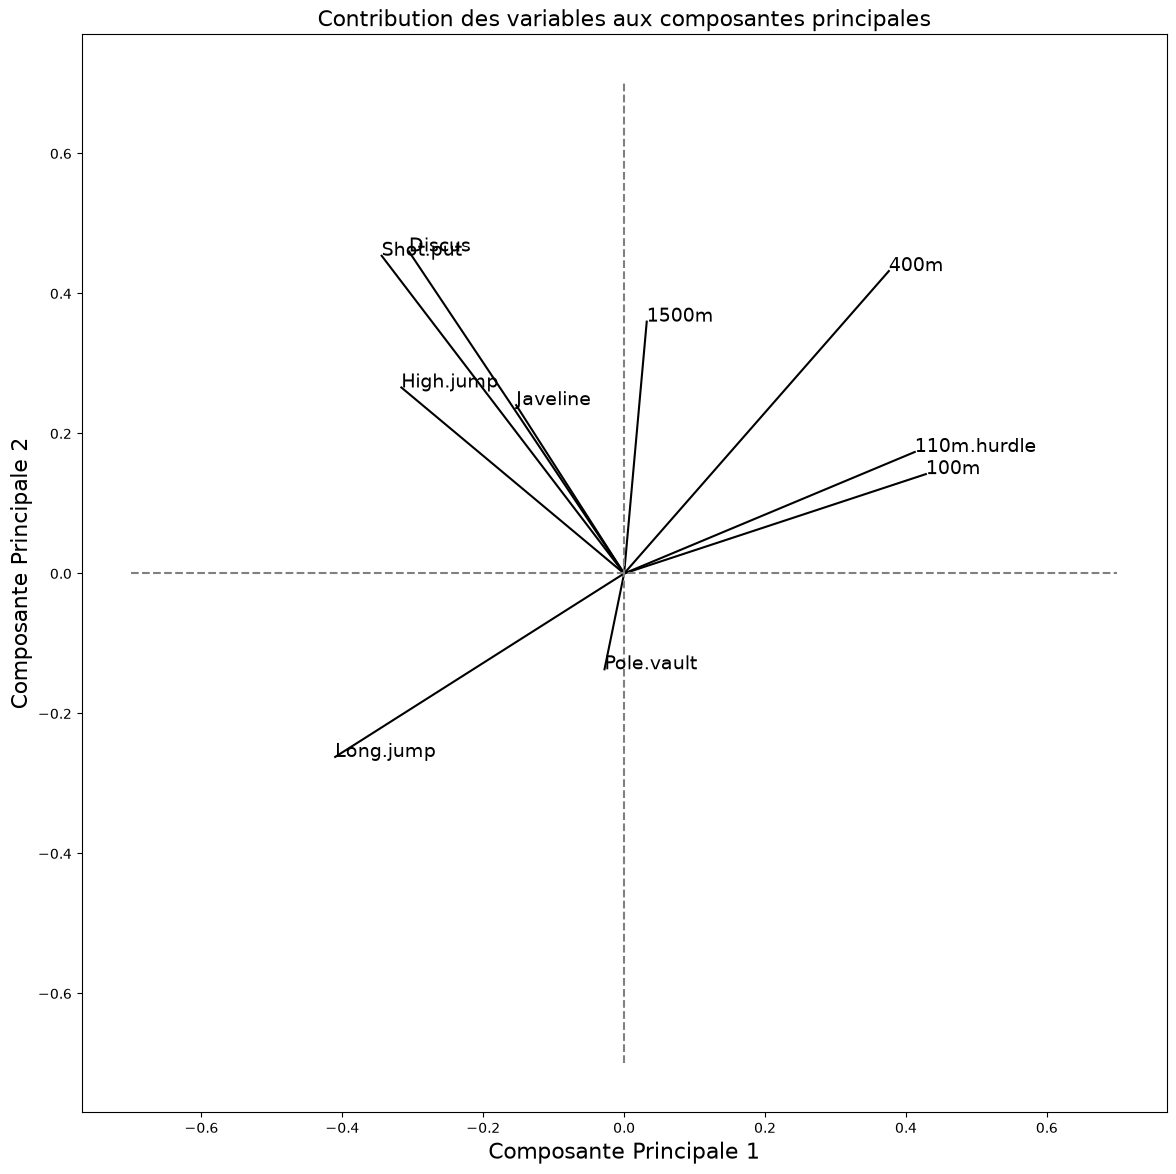

In [7]:
pcs = pca.components_
fig, ax = plt.subplots(1,figsize=(14,14))
for i, (x, y) in enumerate(zip(pcs[0, :], pcs[1, :])):
    # Afficher un segment de l'origine au point (x, y)
    ax.plot([0, x], [0, y], color='k')
    # Afficher le nom (data.columns[i]) de la performance
    plt.text(x, y, data.columns[i], fontsize='14');

# Afficher une ligne horizontale y=0
plt.plot([-0.7, 0.7], [0, 0], color='grey', ls='--');

# Afficher une ligne verticale x=0
plt.plot([0, 0], [-0.7, 0.7], color='grey', ls='--');

ax.set_xlabel("Composante Principale 1", fontsize = 16);
ax.set_ylabel("Composante Principale 2", fontsize = 16);
ax.set_title("Contribution des variables aux composantes principales", fontsize = 16);

#### 1.1.1.2 Autres méthodes linéaires populaires 
- les variantes de l'ACP
- l'Analyse en Composante Indépendantes (ACI)
- L'Analyse Discriminante Linéaire (ADL)
  

#### 1.1.2 Plongements non linéaires

Souvent, les données à grandes dimensions reposent (ou sont proches) sur une **variété non-linéaire** de dimension bien inférieure.

Les méthodes de réduction dimensionnelles non linéaires permettent ainsi de retrouver une approximation de ces variétés et de bien mieux représenter ces données dessus. Dans ce cadre, on peut **généraliser** la notion de **factorisation de matrice** (dont l’ACP fait partie) pour gérer des données qui résident sur une sous-variété non-linéaire

C’est notamment le cas des méthodes de noyaux (ou kernel methods), qui permettent de transformer certains algorithmes linéaires (telle que l’ACP) en algorithmes non linéaires, sans avoir besoin d’effectuer des calculs dans cet espace de dimension supérieure.

#### Exemple de l'ACP à noyau (kernel PCA)

Le plongement d’un espace possédant des propriétés linéaires dans une variété non-linéaire peut s’effectuer à l’aide du **kernel trick**, méthode qui permet d'appliquer la factorisation de dimension à une matrice représentant un **noyau** (plutôt qu'a la matrice de covariance) et qui permet de réprésenter la similarité entre les paires de points de données. Pour plus de détails voir [ce chapitre](https://openclassrooms.com/fr/courses/4379436-explorez-vos-donnees-avec-des-algorithmes-non-supervises/4379521-utilisez-une-acp-avec-un-noyau#/id/r-4444998) 

#### 1.1.3 Apprentissage de variétés (manifold learning)

Une variété, est un espace topologique qui ressemble localement à un [espace euclidien](https://en.wikipedia.org/wiki/Euclidean_space#Technical_definition), c.a.d que chaque point de cet espace possède un [voisinage](https://en.wikipedia.org/wiki/Neighbourhood_(mathematics)) qui est [homéomorphe](https://en.wikipedia.org/wiki/Homeomorphism) à un espace euclidien.
Intuitivement on peut voir une variété comme la généralisation de la notion de courbe.

#### 1.1.3.1 Variétés qui favorisent la structure globale

Il s'agit d'une famille de variété qui permet de traiter le jeu de données avec un focus sur les **distances entre les paires de points**, qu’ils soient distants ou proches.

#### Exemple de MDS (MultiDimensional Scaling)

MDS recherche un espace de représentation des données de faible dimension (2 en général pour la visualisation), dans lequel les distances respectent bien celle de l'espace original à haute dimension des données. 
A partir d'une matrice de similarité, MDS va essayer de réarranger les observations dans un espace de dimension inférieure n) pour se rapprocher au mieux des distances dans l’espace d’origine.

De manière générale, MDS modélise les **similarités** de l'espace de départ par une matrice $S_{ij}$ des similarités entre chaque paire des points du jeu de données (il s'agit souvent de la distance $d_{ij}$ entre les paires de points). Ensuite MDS opère en cherchant à **minimiser la fonction de coût** définissant l'erreur entre les distances approximées $\hat d_{ij}$ dans l'espace d'arrivée et les distances réelles $d_{ij}$  dans l'espace de départ:

$$Cout = \sum\limits_{i<j} (d_{ij} - \hat d_{ij})^2$$
 

In [ ]:
# Authors: Fabian Pedregosa <fabian.pedregosa@inria.fr>
#          Olivier Grisel <olivier.grisel@ensta.org>
#          Mathieu Blondel <mathieu@mblondel.org>
#          Gael Varoquaux
# License: BSD 3 clause (C) INRIA 2011

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import offsetbox
from sklearn import (manifold, datasets, decomposition, ensemble,
                     discriminant_analysis, random_projection, neighbors)
#print(__doc__)
class Embedding():
    def load_data(self, n_neighbors = 30):
        self.digits = datasets.load_digits(n_class=6)
        self.X = self.digits.data
        self.y = self.digits.target
        self.n_neighbors = n_neighbors

    # Plot images of the digits
    def plot_digits(self, ax):
        n_img_per_row = 20
        img = np.zeros((10 * n_img_per_row, 10 * n_img_per_row))
        for i in range(n_img_per_row):
            ix = 10 * i + 1
            for j in range(n_img_per_row):
                iy = 10 * j + 1
                img[ix:ix + 8, iy:iy + 8] = self.X[i * n_img_per_row + j].reshape((8, 8))

        ax.imshow(img, cmap=plt.cm.binary);
        ax.set_xticks([]);
        ax.set_yticks([]);
        ax.set_title('A selection from the 64-dimensional digits dataset');

    # Scale and visualize the embedding vectors
    def plot_embedding(self, X, ax=None, title=None):
        x_min, x_max = np.min(X, 0), np.max(X, 0)
        X = (X - x_min) / (x_max - x_min)

        plt.figure();
        if ax == None:
            ax = plt.subplot(111);
        for i in range(X.shape[0]):
            ax.text(X[i, 0], X[i, 1], str(self.y[i]),
                     color=plt.cm.Set1(self.y[i] / 10.),
                     fontdict={'weight': 'bold', 'size': 9});

        if hasattr(offsetbox, 'AnnotationBbox'):
            # only print thumbnails with matplotlib > 1.0
            shown_images = np.array([[1., 1.]])  # just something big
            for i in range(X.shape[0]):
                dist = np.sum((X[i] - shown_images) ** 2, 1)
                if np.min(dist) < 4e-3:
                    # don't show points that are too close
                    continue
                shown_images = np.r_[shown_images, [X[i]]]
                imagebox = offsetbox.AnnotationBbox(
                    offsetbox.OffsetImage(self.digits.images[i], cmap=plt.cm.gray_r),
                    X[i])
                ax.add_artist(imagebox);
        ax.set_xticks([]), ax.set_yticks([])
        if title is not None:
            ax.set_title(title);
            
if __name__ == "__main__":
    em = Embedding()

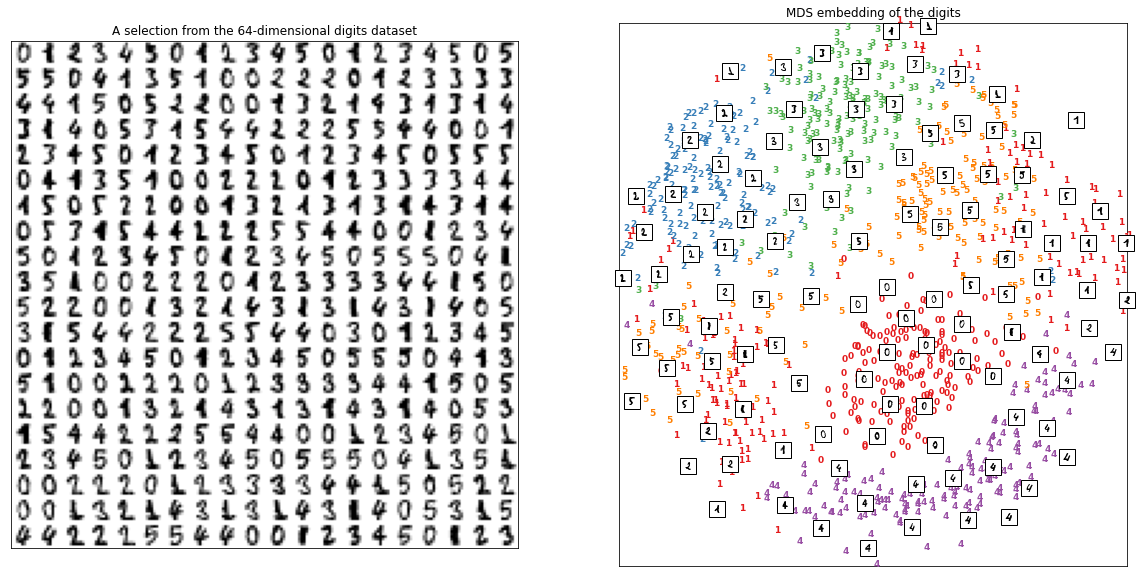

<Figure size 432x288 with 0 Axes>

In [ ]:
em.load_data()
# ----------------------------------------------------------------------
fig, (ax1,ax2) = plt.subplots(1,2,figsize = (20,10));
em.plot_digits(ax1)

# ----------------------------------------------------------------------
# MDS  embedding of the digits dataset
clf = manifold.MDS(n_components=2, n_init=1, max_iter=100)
X_mds = clf.fit_transform(em.X)
em.plot_embedding(X_mds, ax=ax2, title= "MDS embedding of the digits")

#### Exemple de Isomap (Isometric maping)

Isomap peut être vue comme une extension de l'algorithme MDS dans la mesure où il recherche le plongement vers un espace d'arrivée (de faible dimension) en respectant la **distance géodésique** entre tous les points. Pour un exemple détaillé voir [ce chapitre](https://openclassrooms.com/fr/courses/4379436-explorez-vos-donnees-avec-des-algorithmes-non-supervises/4379526-decouvrez-une-variete-qui-conserve-la-structure-globale#/id/r-4445087)

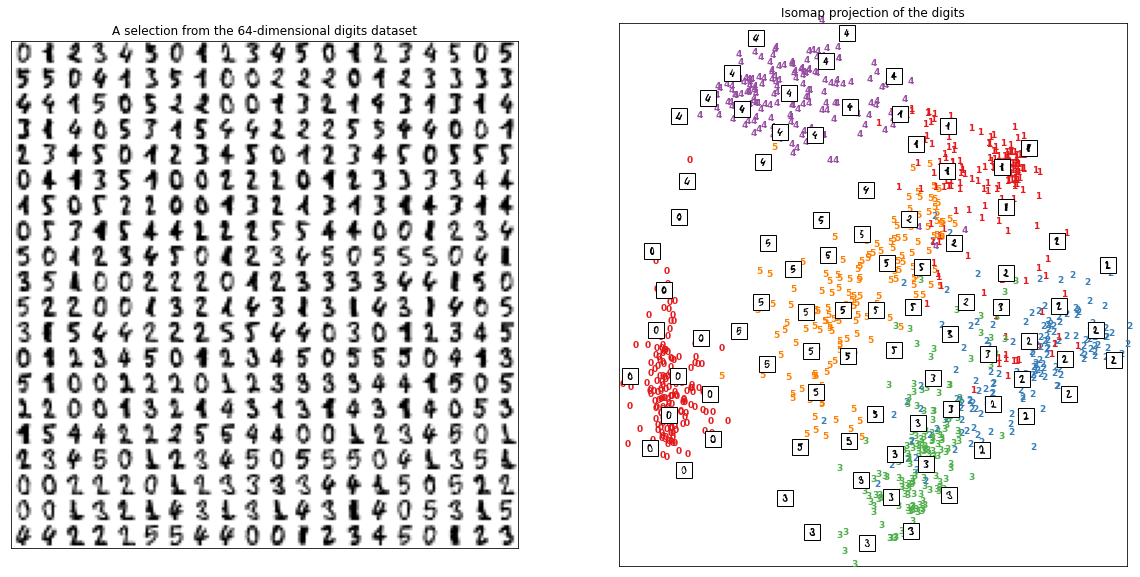

<Figure size 432x288 with 0 Axes>

In [ ]:
em.load_data()
# ----------------------------------------------------------------------
fig, (ax1,ax2) = plt.subplots(1,2,figsize = (20,10));
em.plot_digits(ax1)

# ----------------------------------------------------------------------
# Isomap projection of the digits dataset
X_iso = manifold.Isomap(n_neighbors=em.n_neighbors, n_components=2
                        ).fit_transform(em.X)
em.plot_embedding(X_iso, ax=ax2, title="Isomap projection of the digits");


#### 1.1.3.2 Variétés qui favorisent la structure locale

Il s'agit de méthodes qui favorisent la structure locale du phénomène observé. L’objectif n’est donc pas de retrouver la variété globale d’origine mais de souligner certains comportement des données à l’échelle locale, en mettant en exergue cette fois les paires de distances euclidiennes entre les points proches.

L'avantage de cette stratégie réside dans le fait qu'on ouvre ainsi la possibilité de trouver des représentations plus fidèles de notre jeu de données sur une plus large classe de variété.

#### Exemple de l'algorithme Locally Linear Embedding (LLE)

LLE recherche un plongement de l'espace de départ des données dans un espace de plus faible dimension, en **préservant les distances locales entre points voisins**.
Premièrement, dans l'espace de départ, LLE cherche comment reconstruire chaque point à l’aide de ses K plus proches voisins, en minimisant la fonction suivante :
$$Min_{W} E = ||X−WV(X)||$$

Où V(X) représente la matrice des K voisins de X. On obtient ainsi la matrice W.

A l’aide de cette matrice, on veut trouver les points Y dans la variété de dimension inférieure en minimisant: 

$$𝑀𝑖𝑛_𝑊 E = ||Y−𝑊Y||$$

*De manière résumée, LLE peut être vue comme in série de PCA calculée localement qui sont enusite comparées globalement pour trouver le meilleur plongement non linéaire*

Reconstruction error: 2.11987e-06


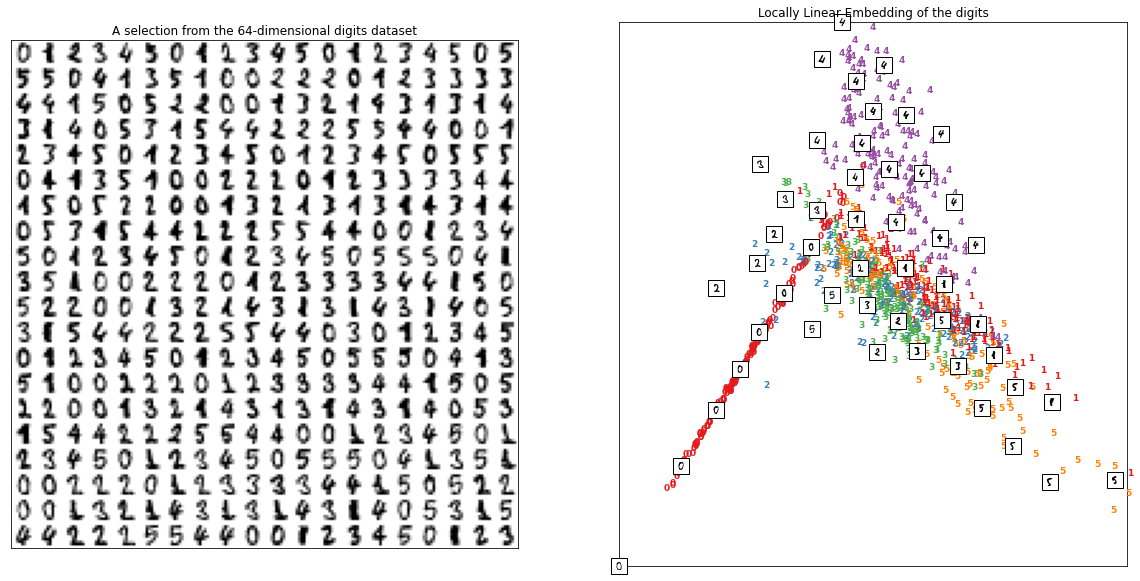

<Figure size 432x288 with 0 Axes>

In [ ]:
em.load_data()
# ----------------------------------------------------------------------
fig, (ax1,ax2) = plt.subplots(1,2,figsize = (20,10));
em.plot_digits(ax1)

# ----------------------------------------------------------------------
# Locally linear embedding of the digits dataset
clf = manifold.LocallyLinearEmbedding(n_neighbors=em.n_neighbors, n_components=2,
                                      method='standard')
X_lle = clf.fit_transform(em.X)
print("Reconstruction error: %g" % clf.reconstruction_error_)
em.plot_embedding(X_lle, ax=ax2, title= "Locally Linear Embedding of the digits")

#### **Exemple de l'algorithme t-Stochastic Neighbour Embedding (t-SNE)**

#### Principe et généralités

Il s'agit d'une des méthodes de visualisation les plus usitées, elle est populaire pour sa capacité à générer des visualisations très parlantes qui peuvent orienter par la suite le data scientist dans son travail de modélisation.

Le concept général de l’algorithme est de modéliser l'**affinité** entre les points de données en assignant à chaque point une **probabilité gaussienne jointe (poids)** en fonction de l'affinité de chaque point avec ses voisins. 

Une fois toutes ces probabilités calculées $P_{ij}$ , on peut **plonger** dans une dimension inférieure notre jeu de données en calculant une nouvelle distribution $Q_{ij}$ (qui est une t-student distribution cette fois, d’où le “t”), qui minimise la [divergence Kullback-Leibler (KL)](https://en.wikipedia.org/wiki/Kullback%E2%80%93Leibler_divergence) entre $P$ et $Q$ comme fonction de coût.

L’idée est de trouver un espace de dimension inférieure mais qui respecte une distribution proche (en divergence KL) de la distribution d’origine

/shared-libs/python3.7/py/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:793: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  FutureWarning,
/shared-libs/python3.7/py/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:986: FutureWarning: The PCA initialization in TSNE will change to have the standard deviation of PC1 equal to 1e-4 in 1.2. This will ensure better convergence.
  FutureWarning,


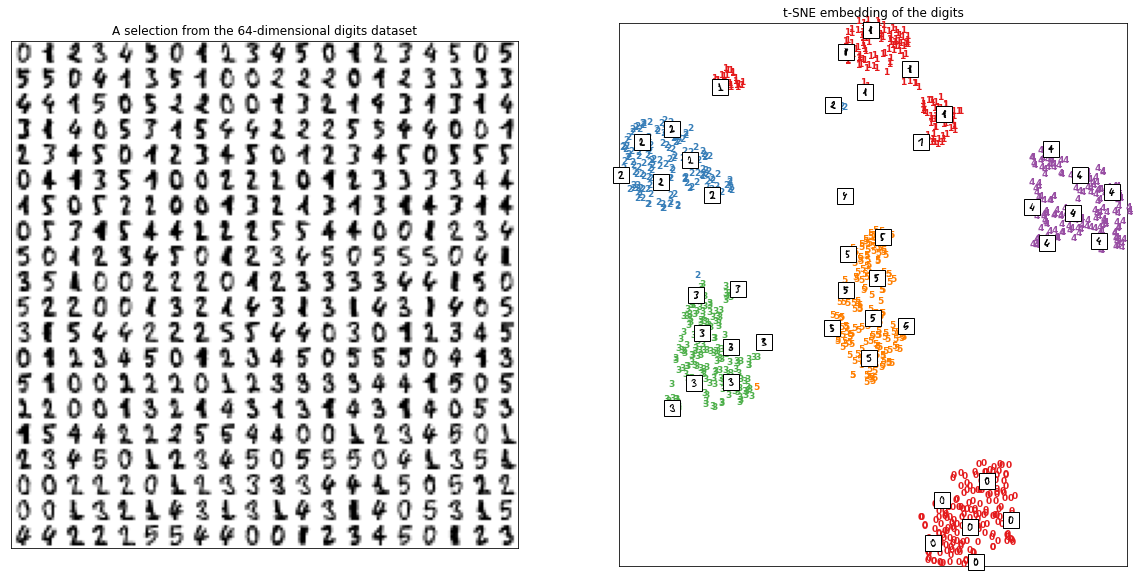

<Figure size 432x288 with 0 Axes>

In [ ]:
em.load_data()
# ----------------------------------------------------------------------
fig, (ax1,ax2) = plt.subplots(1,2,figsize = (20,10));
em.plot_digits(ax=ax1)

# ----------------------------------------------------------------------
tsne = manifold.TSNE(n_components=2, perplexity=30, init='pca', random_state=0)
X_tsne = tsne.fit_transform(em.X)
em.plot_embedding(X_tsne, ax=ax2, title="t-SNE embedding of the digits")

#### Avantages et incovénients

**Avantages de t-SNE**:

Par rapport aux autres méthodes de plongement:
- est capable de réveler des données qui vivent dans des variétés ou des des clusters différents
- est capable de réveler sur une simple carte des structures de différentes échelles
- peut capturer différentes formes et/ou des clusters
- peut capturer des topologies complexes (en examinant plusieurs visualisations)

Comme beaucoup de méthodes de plongements:
- si t-SNE vous fournit un clustering satisfaisant (avec des groupes assez bien séparés) par rapport à une PCA linéaire classique, vous pourrez utiliser les composantes obtenues comme entrée pour d'autres algorithmes (par exemples pour une tâche de classification) et espérer obtenir des meilleurs résultats qu'avec les données représentées dans leur espace à grande dimension.

- si vous avez créé des features qui vous semblent représentatives des distinctions entre les données, ces distinctions pourront se retrouver lors de la visualisation du t-SNE qui peut alors vous servir de validation de la qualité des features crées

**Inconvénients de t-SNE**:
- t-SNE tend à ne pas préserver la structure globale du jeu de données (représenté en haute dimension). Il est possible d'atténuer ce problème en utilisant plusieurs visualisations (une t-SNE pour observer la structure locale, et PCA ou Isomap pour la structure globale par exemple). Une autre solution est d’initialiser l’algorithme t-SNE par une PCA avant de le lancer (avec l'optioninit=’pca’), ce qui permet de conserver de base un peu plus de la structure globale 
- De part sa nature stochastique, il peut conduire à des résultats différents chaque fois qu'il est lancé. On peut dans ce cas choisir le résultat ayant obtenu l'erreur minimale
- il est computationnellement lourd (peut prendre jusqu'a une heure sur un dataset d'un million de ligne)


#### Hyper-paramètres: importance de la perplexité

t-SNE, possède des **hyper paramètres** qu'il faudra apprendre à régler, pour développer une petite intuition de ses différents comportements sur des cas simples afin de pouvoir comprendre un peu mieux les plongements et les visualisations créées et les interpréter correctement.

Parmi ces hyper paramètres, les suivants impactent généralement le plus son comportement:
- ***la perplexité*** : c'est le paramètre le plus impactant

Elle représente la taille de la variance de $P_{ij}$. On peut la voir grossièrement comme la **balance entre prise en compte de la structure globale et locale**, c’est à dire une estimation du nombre de voisins “proches” (relativement à l’ensemble du jeu de données) que possède chaque points.*Typiquement, vous pouvez tester une valeur de la **perplexité entre 5 et 50** à partir de 5-10k observations*

- ***nombre d'iteration*** : le nombre d'iteration de l'optimiseur (la descente de gradient).

Il conditionne principalement la convergence de l'algorithme dans un **minimum local de la fonction de coût**. Attention différents runs avec différentes ilitialisations peuvent conduire à différents minimum locaux, il convient généralement de sélectionner le run avec le plus petit minimum local.

- ***learning rate***: conditionne le pas de la descente de gradient 


[Cet excellent article](https://distill.pub/2016/misread-tsne/) présente en détail et de manière intéractive certains des hyper paramètres et leur influence sur la visualisation des données issues de t-SNE

#### Interprétation de la visualisation

il existe pléthore d’erreurs d’interprétation possible, sur tous les autres aspects du phénomène : la taille des cluster n’est pas significative, ni la distance entre les différents clusters, difficile de détecter la topologie (i.e. si une catégorie de points est contenue dans l’autre). Attention à ne pas surinterpréter les visualisations !

De plus comme évoqué plus haut, les résultats de la visualisation peuvent fortement dépendre de certains hyper paramètres comme la perplexité et le nombre d'itération. Je vous conseille, lors de l'usage de t-SNE, de **toujours lancer différents run** en faisant varier, a minima, ces deux hyper paramètres

### 1.1.4 Comparison de méthodes d'apprentissage de variétés

La librairie scikit-learn propose une comparaison des nombreuses méthodes d'apprentissages de variétés sur différents jeu de données artificiels possédant des géométries différentes : un [S](https://scikit-learn.org/stable/auto_examples/manifold/plot_compare_methods.html#comparison-of-manifold-learning-methods) ou une [sphère](https://scikit-learn.org/stable/auto_examples/manifold/plot_manifold_sphere.html#manifold-learning-methods-on-a-severed-sphere)

### Pour aller plus loin

- [Ce cours dédié à l'exploration de données avec des algorithmes non supervisés](https://openclassrooms.com/fr/courses/4379436-explorez-vos-donnees-avec-des-algorithmes-non-supervises)
- La section de scikit-learn dediée aux [problèmes de factorisation de matrices](href="https://scikit-learn.org/stable/modules/decomposition.html#decomposing-signals-in-components-matrix-factorization-problems)
- La section de scikit-learn dédiée à [l'apprentissage de variété](https://scikit-learn.org/stable/modules/manifold.html#manifold-learning)